Objective is To display movies recommendation by five users by using Netflix Combined data and Title data.

Importing required basic libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import zipfile


In [3]:
import warnings
warnings.filterwarnings('ignore')

Loading data through drive

In [7]:
netflix_dataset=pd.read_csv("combined_data_1.txt.zip", header = None, usecols = [0,1], names = ["Cust_ID","Rating"])

In [8]:
netflix_dataset

,Cust_ID,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


Understanding dataset

In [9]:
netflix_dataset['Cust_ID'].nunique()

475257

In [10]:
netflix_dataset[25 : 50]

,Cust_ID,Rating
25,1181550,3.0
26,1227322,4.0
27,427928,4.0
28,814701,5.0
29,808731,4.0
30,662870,5.0
31,337541,5.0
32,786312,3.0
33,1133214,4.0
34,1537427,4.0


In [11]:
netflix_dataset.head()

,Cust_ID,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0


Preprocessing Section

In [12]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24058263 entries, 0 to 24058262
Data columns (total 2 columns):
 #   Column   Dtype  
---  ------   -----  
 0   Cust_ID  object 
 1   Rating   float64
dtypes: float64(1), object(1)
memory usage: 367.1+ MB


In [13]:
netflix_dataset.isnull().sum()

Cust_ID       0
Rating     4499
dtype: int64

In [14]:
netflix_dataset['Cust_ID'].nunique()

475257

In [15]:
netflix_dataset[netflix_dataset['Cust_ID'] == 1]


,Cust_ID,Rating


In [16]:
netflix_dataset[netflix_dataset['Cust_ID'] == '1:']

,Cust_ID,Rating
0,1:,NaN


In [17]:
netflix_dataset[netflix_dataset['Rating'] == 'NaN' ]

,Cust_ID,Rating


In [18]:
netflix_dataset[netflix_dataset['Rating'] == 0 ]

,Cust_ID,Rating


In [19]:
netflix_dataset['Rating'].isnull().sum()

np.int64(4499)

In [20]:
movie_count=netflix_dataset.isnull().sum()["Rating"]

In [21]:
movie_count

np.int64(4499)

In [22]:
customer_count = netflix_dataset["Cust_ID"].nunique() - movie_count

In [23]:
customer_count

np.int64(470758)

In [24]:
rating_count=len(netflix_dataset) - movie_count

In [25]:
rating_count

np.int64(24053764)

In [26]:
netflix_dataset

,Cust_ID,Rating
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [27]:
movie_id=None
movie_np=[]
for cust_id in netflix_dataset["Cust_ID"]:
  if ':' in cust_id:
    movie_id=int(cust_id.replace(":",""))
  movie_np.append(movie_id)

In [28]:
movie_np[0]

1

In [29]:
movie_np[-1]

4499

In [30]:
len(movie_np)

24058263

Adding / Creating additional column to dataset

In [31]:
netflix_dataset["Movie_ID"] = movie_np

In [32]:
netflix_dataset

,Cust_ID,Rating,Movie_ID
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


Data cleaning

In [33]:
netflix_dataset.isnull().sum()

Cust_ID        0
Rating      4499
Movie_ID       0
dtype: int64

In [34]:
netflix_dataset.dropna(inplace=True)

In [35]:
netflix_dataset

,Cust_ID,Rating,Movie_ID
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [36]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_ID   object 
 1   Rating    float64
 2   Movie_ID  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [37]:
netflix_dataset["Cust_ID"]=netflix_dataset["Cust_ID"].astype(int)

In [38]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_ID   int64  
 1   Rating    float64
 2   Movie_ID  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


Filtering movies with less rating

In [39]:
data_movie_summary = netflix_dataset.groupby("Movie_ID")["Rating"].count()

In [40]:
data_movie_summary

Movie_ID
1        547
2        145
3       2012
4        142
5       1140
        ... 
4495     614
4496    9519
4497     714
4498     269
4499     428
Name: Rating, Length: 4499, dtype: int64

In [41]:
data_movie_summary.shape

(4499,)

In [43]:
data_movie_summary.max()

np.int64(193941)

In [44]:
data_movie_summary.min()

np.int64(36)

In [45]:
data_movie_summary.sum()

np.int64(24053764)

In [46]:
data_movie_summary.quantile(0.60)

np.float64(907.7999999999997)

In [47]:
movie_benchmark = round(data_movie_summary.quantile(0.6))
movie_benchmark

908

In [48]:
Rejected_movies = data_movie_summary[data_movie_summary < movie_benchmark].index
Rejected_movies

Index([   1,    2,    4,    7,    9,   10,   11,   12,   13,   14,
       ...
       4480, 4481, 4486, 4487, 4491, 4494, 4495, 4497, 4498, 4499],
      dtype='int64', name='Movie_ID', length=2699)

In [49]:
len(Rejected_movies)

2699

Filtering and excluding customers who have rated least movies

In [50]:
data_cust_summary=netflix_dataset.groupby("Cust_ID")["Rating"].count()

In [51]:
data_cust_summary

Cust_ID
6          153
7          195
8           21
10          49
25           4
          ... 
2649404     12
2649409     10
2649421      3
2649426     74
2649429     62
Name: Rating, Length: 470758, dtype: int64

In [52]:
data_cust_summary.shape

(470758,)

In [53]:
data_cust_summary.max()

np.int64(4467)

In [54]:
data_cust_summary.min()

np.int64(1)

In [55]:
cust_benchmark = round(data_cust_summary.quantile(0.6))
cust_benchmark

36

In [56]:
Rejected_cust = data_cust_summary[data_cust_summary<cust_benchmark].index
Rejected_cust

Index([      8,      25,      33,      83,      94,     126,     130,     133,
           142,     149,
       ...
       2649337, 2649343, 2649351, 2649376, 2649379, 2649384, 2649401, 2649404,
       2649409, 2649421],
      dtype='int64', name='Cust_ID', length=282042)

In [57]:
len(Rejected_cust)

282042

Updating dataset on the basis of Rejected_movies

In [58]:
netflix_dataset = netflix_dataset[~netflix_dataset["Movie_ID"].isin(Rejected_movies)]

In [59]:
netflix_dataset['Movie_ID'].isin(Rejected_movies)

695         False
696         False
697         False
698         False
699         False
            ...  
24056844    False
24056845    False
24056846    False
24056847    False
24056848    False
Name: Movie_ID, Length: 23218285, dtype: bool

In [60]:
netflix_dataset

,Cust_ID,Rating,Movie_ID
695,1025579,4.0,3
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
...,...,...,...
24056844,267802,4.0,4496
24056845,1559566,3.0,4496
24056846,293198,3.0,4496
24056847,70814,2.0,4496


Updating dataset based on Rejected customers

In [61]:
netflix_dataset=netflix_dataset[~netflix_dataset["Cust_ID"].isin(Rejected_cust)]


In [62]:
netflix_dataset['Cust_ID'].isin(Rejected_cust)

696         False
697         False
698         False
699         False
700         False
            ...  
24056842    False
24056843    False
24056844    False
24056845    False
24056846    False
Name: Cust_ID, Length: 19695836, dtype: bool

Updated dataset

In [63]:
netflix_dataset

,Cust_ID,Rating,Movie_ID
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [64]:
netflix_dataset.shape

(19695836, 3)

In [65]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19695836 entries, 696 to 24056846
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_ID   int64  
 1   Rating    float64
 2   Movie_ID  int64  
dtypes: float64(1), int64(2)
memory usage: 601.1 MB


In [66]:
netflix_dataset.isnull().sum()

Cust_ID     0
Rating      0
Movie_ID    0
dtype: int64

Model Preparation and Implementation Section

Loading Movie Title data

In [81]:
df_title = pd.read_csv("movie_titles.csv", encoding="ISO-8859-1",header=None,names=["Movie_ID","Year","Name"],usecols=[0,1,2])

In [82]:
df_title

,Movie_ID,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [83]:
df_title.shape

(17770, 3)

In [84]:
df_title.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17770 entries, 0 to 17769
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Movie_ID  17770 non-null  int64  
 1   Year      17763 non-null  float64
 2   Name      17770 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 416.6+ KB


In [85]:
df_title.isnull().sum()

Movie_ID    0
Year        7
Name        0
dtype: int64

Not droping null values (only 7) as it hardly make any difference.

In [86]:
last_movie_year = df_title['Year'].max()
last_movie_year

np.float64(2005.0)

In [87]:
first_movie_year = df_title['Year'].min()
first_movie_year

np.float64(1896.0)

In [92]:
total_movie_years = last_movie_year - first_movie_year
total_movie_years

np.float64(109.0)

In [93]:
df_title['Year'].unique()

array([2003., 2004., 1997., 1994., 1992., 1991., 2001., 1999., 1947.,
       1982., 1988., 1996., 2005., 2000., 1972., 2002., 1981., 1962.,
       1973., 1964., 1952., 1941., 1995., 1969., 1943., 1989., 1974.,
       1954., 1956., 1979., 1951., 1983., 1998., 1985., 1965., 1993.,
       1976., 1957., 1987., 1927., 1978., 1975., 1971., 1939., 1968.,
       1980., 1950., 1921., 1918., 1942., 1959., 1958., 1966., 1935.,
       1967., 1948., 1990., 1984., 1937., 1986., 1916., 1946., 1970.,
       1963., 1961., 1931., 1960., 1955., 1940., 1977., 1953., 1944.,
       1928., 1945., 1930., 1936., 1938., 1929., 1932., 1949., 1933.,
       1925., 1922., 1924., 1934., 1920., 1915., 1926., 1917.,   nan,
       1909., 1919., 1923., 1896., 1914.])

In [94]:
df_title['Year'].nunique()

94

Installing and importing surprise library for cross validation and recommendation

In [100]:
!pip install Scikit-surprise

  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build Scikit-surprise


  error: subprocess-exited-with-error
  
  × Building wheel for Scikit-surprise (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [155 lines of output]
      C:\Users\Shekhar mishra\AppData\Local\Temp\pip-build-env-ui0ift8o\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
      !!
      
              ********************************************************************************
              Please use a simple string containing a SPDX expression for `project.license`. You can also use `project.license-files`. (Both options available on setuptools>=77.0.0).
      
              By 2026-Feb-18, you need to update your project and remove deprecated calls
              or your builds will no longer be supported.
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              *******************************

In [ ]:
from surprise import Reader, Dataset, SVD
from surprise.model_selection import cross_validate

In [ ]:
reader=Reader()

Data slicing and formating for cross validation and recommendation

In [ ]:
data=Dataset.load_from_df(netflix_dataset[["Cust_ID","Movie_ID","Rating"]][:1000000],reader)

In [ ]:
data

Creating Recommendation model SVD ( Singular Value Decomposition )

In [ ]:
model=SVD()

Model validation using accuracy matrics

In [ ]:
cross_validate(model,data,measures=["RMSE"],cv=3)

{'test_rmse': array([0.96914276, 0.96804078, 0.96984536]),
 'fit_time': (13.94253921508789, 15.63955545425415, 14.335254669189453),
 'test_time': (4.719117879867554, 2.763380527496338, 3.939805030822754)}

In [ ]:
cross_validate(model,data,measures=["MSE"],cv=3)

{'test_mse': array([0.93936868, 0.93703551, 0.94114247]),
 'fit_time': (14.752154111862183, 15.999511957168579, 14.7100830078125),
 'test_time': (4.872328281402588, 4.009281635284424, 3.4804649353027344)}

In [ ]:
cross_validate(model,data,measures=["MAE"],cv=3 )

{'test_mae': array([0.7582576 , 0.75722844, 0.75774601]),
 'fit_time': (13.93141770362854, 14.622865438461304, 18.46955966949463),
 'test_time': (2.7828266620635986, 2.8881995677948, 3.4135799407958984)}

In [ ]:
cross_validate(model,data,measures=["FCP"],cv=3 )

{'test_fcp': array([0.57751353, 0.57573295, 0.57356696]),
 'fit_time': (14.305385828018188, 14.701227188110352, 14.452988147735596),
 'test_time': (3.6588339805603027, 2.838686466217041, 2.714189052581787)}

Inference : Out of above four accuracy matrics RMSE gives best accucary.

Recommendation Section

In [ ]:
df_title.head(5)

,Movie_ID,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


In [ ]:
netflix_dataset

,Cust_ID,Rating,Movie_ID
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


Selecting user on the basis of random pick for recommendation analysis

Manual Random Pick

Recommendation by user one

In [ ]:
user_number_1331154 = df_title.copy()

In [ ]:
user_number_1331154["Estimate_Score"]=user_number_1331154["Movie_ID"].apply(lambda x: model.predict(1331154,x).est)

In [ ]:
user_number_1331154=user_number_1331154.sort_values("Estimate_Score",ascending=False)

In [ ]:
user_number_1331154.head(10)

,Movie_ID,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
6,7,1992.0,8 Man
7,8,2004.0,What the #$*! Do We Know!?
8,9,1991.0,Class of Nuke 'Em High 2
9,10,2001.0,Fighter


In [ ]:
user_number_1331154['Name'].head(10)

,Name
45,Rudolph the Red-Nosed Reindeer
17,Immortal Beloved
56,Richard III
269,Sex and the City: Season 4
208,Star Trek: Deep Space Nine: Season 5
166,The Chorus
87,Record of Lodoss War: Chronicles of the Heroic...
105,Stevie Ray Vaughan and Double Trouble: Live at...
240,North by Northwest
137,Star Trek: Voyager: Season 1


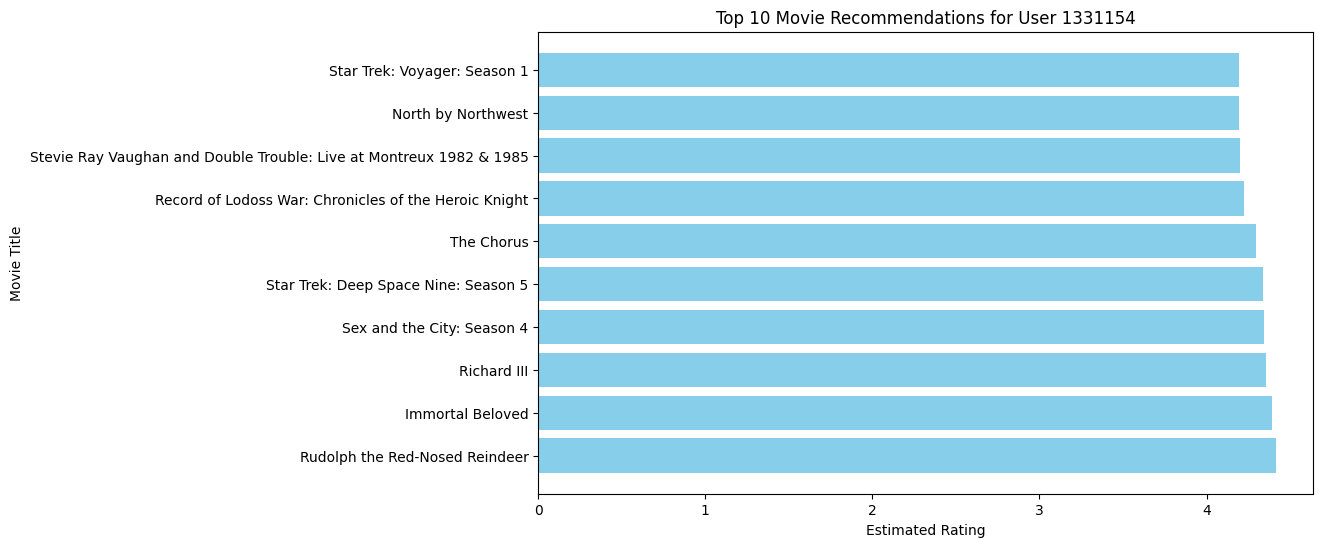

In [ ]:
## Visualize the top 10 recommendations

top_10_recommendations = user_number_1331154.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_10_recommendations['Name'], top_10_recommendations['Estimate_Score'], color='skyblue')
plt.xlabel('Estimated Rating')
plt.ylabel('Movie Title')
plt.title('Top 10 Movie Recommendations for User 1331154')
#plt.gca().invert_yaxis()
plt.show()

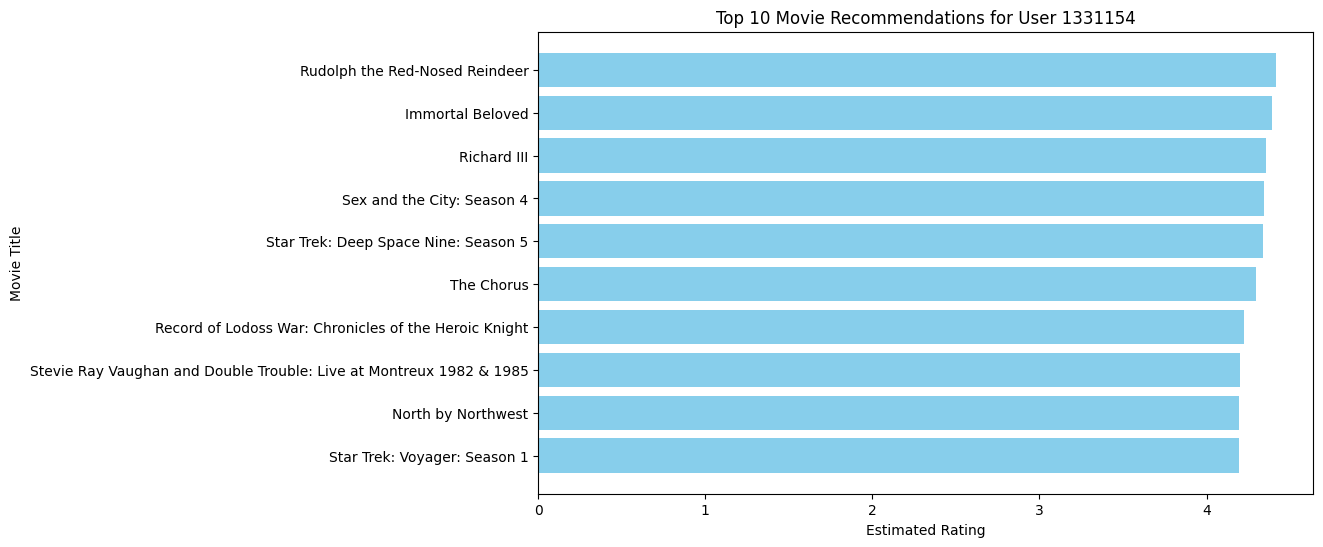

In [ ]:
# Visualize the top 10 recommendations (top 10 descending figures)

top_10_recommendations = user_number_1331154.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_10_recommendations['Name'], top_10_recommendations['Estimate_Score'], color='skyblue')
plt.xlabel('Estimated Rating')
plt.ylabel('Movie Title')
plt.title('Top 10 Movie Recommendations for User 1331154')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
netflix_dataset

,Cust_ID,Rating,Movie_ID
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


Recommendation by user number two

In [ ]:
user_number_1055714 = df_title.copy()

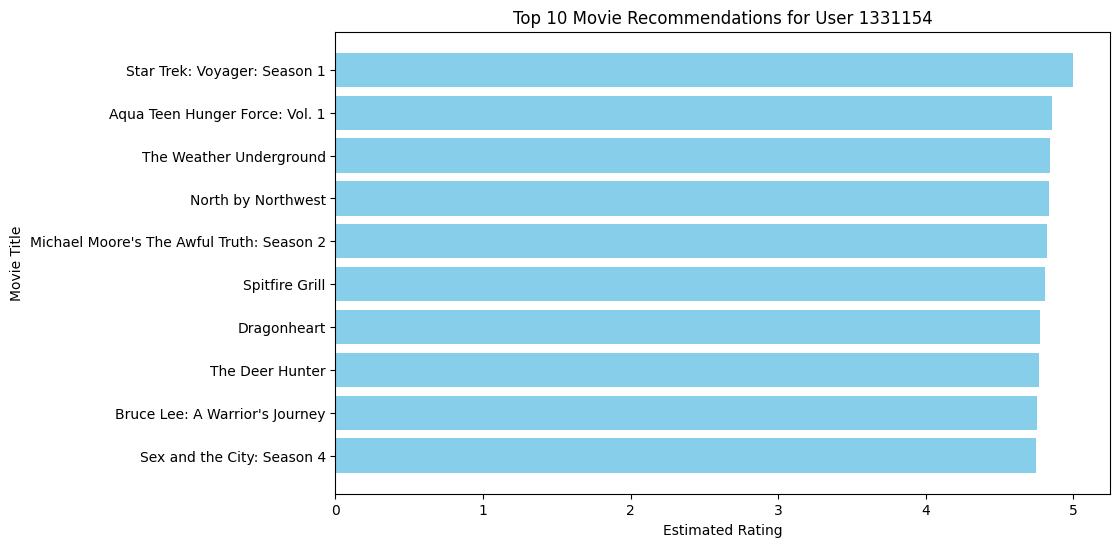

In [ ]:
# Step 1: Predict the ratings
user_number_1055714 = df_title.copy()
user_number_1055714 = user_number_1055714[~user_number_1055714["Movie_ID"].isin(Rejected_movies)]
user_number_1055714["Estimate_Score"] = user_number_1055714["Movie_ID"].apply(lambda x: model.predict(1055714, x).est)

# Step 2: Sort the predictions
user_number_1055714 = user_number_1055714.sort_values("Estimate_Score", ascending=False)

# Step 3: Visualize the top 10 recommendations
top_10_recommendations = user_number_1055714.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_10_recommendations['Name'], top_10_recommendations['Estimate_Score'], color='skyblue')
plt.xlabel('Estimated Rating')
plt.ylabel('Movie Title')
plt.title('Top 10 Movie Recommendations for User 1331154')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
user_number_1055714.head(10)

,Movie_ID,Year,Name,Estimate_Score
137,138,1995.0,Star Trek: Voyager: Season 1,5.000000
32,33,2000.0,Aqua Teen Hunger Force: Vol. 1,4.855589
51,52,2002.0,The Weather Underground,4.842429
240,241,1959.0,North by Northwest,4.836269
247,248,2001.0,Michael Moore's The Awful Truth: Season 2,4.821456
43,44,1996.0,Spitfire Grill,4.810103
57,58,1996.0,Dragonheart,4.772854
198,199,1978.0,The Deer Hunter,4.765914
112,113,2000.0,Bruce Lee: A Warrior's Journey,4.751154
269,270,2001.0,Sex and the City: Season 4,4.744649


Recommendation by user number three

In [ ]:
user_number_293198 = df_title.copy()

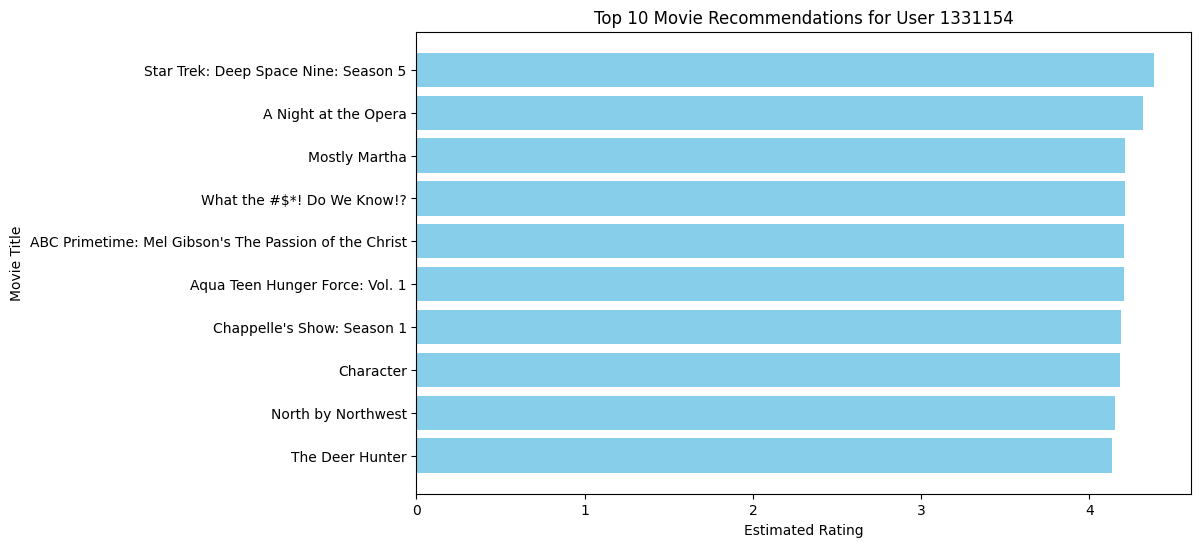

In [ ]:
# Step 1: Predict the ratings
user_number_293198 = df_title.copy()
user_number_293198 = user_number_293198[~user_number_293198["Movie_ID"].isin(Rejected_movies)]
user_number_293198["Estimate_Score"] = user_number_293198["Movie_ID"].apply(lambda x: model.predict(293198, x).est)

# Step 2: Sort the predictions
user_number_293198 = user_number_293198.sort_values("Estimate_Score", ascending=False)

# Step 3: Visualize the top 10 recommendations
top_10_recommendations = user_number_293198.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_10_recommendations['Name'], top_10_recommendations['Estimate_Score'], color='skyblue')
plt.xlabel('Estimated Rating')
plt.ylabel('Movie Title')
plt.title('Top 10 Movie Recommendations for User 1331154')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
user_number_293198.head(10)

,Movie_ID,Year,Name,Estimate_Score
208,209,1996.0,Star Trek: Deep Space Nine: Season 5,4.387080
252,253,1935.0,A Night at the Opera,4.321409
96,97,2002.0,Mostly Martha,4.211048
7,8,2004.0,What the #$*! Do We Know!?,4.209415
31,32,2004.0,ABC Primetime: Mel Gibson's The Passion of the...,4.207094
32,33,2000.0,Aqua Teen Hunger Force: Vol. 1,4.202940
222,223,2003.0,Chappelle's Show: Season 1,4.190598
2,3,1997.0,Character,4.180762
240,241,1959.0,North by Northwest,4.154117
198,199,1978.0,The Deer Hunter,4.137032


Recommendation by user number four

In [ ]:
user_number_267802 = df_title.copy()

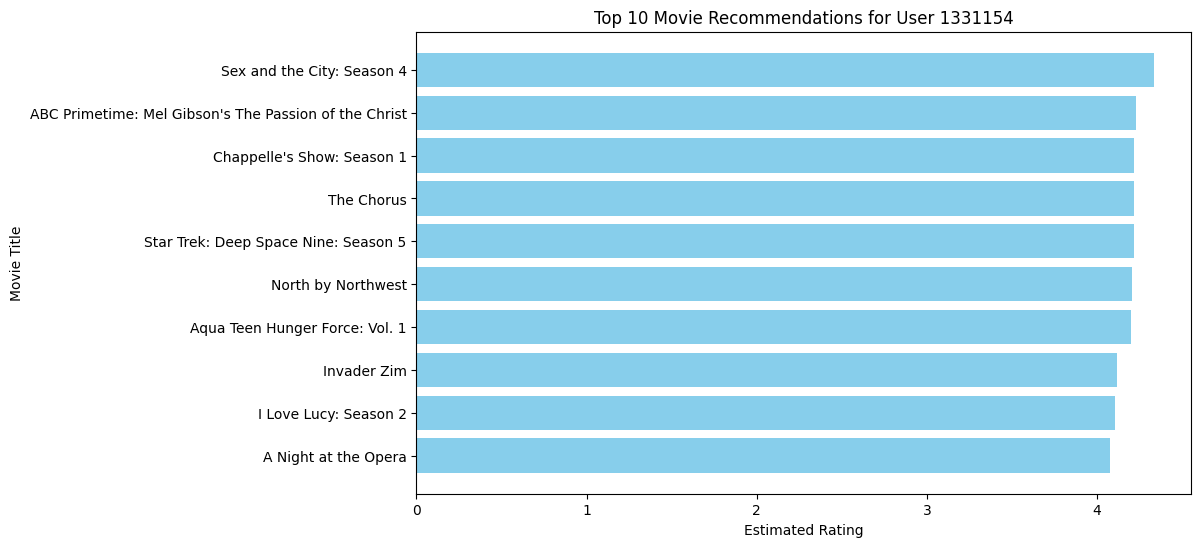

In [ ]:
# Step 1: Predict the ratings
user_number_267802 = df_title.copy()
user_number_267802 = user_number_267802[~user_number_267802["Movie_ID"].isin(Rejected_movies)]
user_number_267802["Estimate_Score"] = user_number_267802["Movie_ID"].apply(lambda x: model.predict(267802, x).est)

# Step 2: Sort the predictions
user_number_267802 = user_number_267802.sort_values("Estimate_Score", ascending=False)

# Step 3: Visualize the top 10 recommendations
top_10_recommendations = user_number_267802.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_10_recommendations['Name'], top_10_recommendations['Estimate_Score'], color='skyblue')
plt.xlabel('Estimated Rating')
plt.ylabel('Movie Title')
plt.title('Top 10 Movie Recommendations for 1331154')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
user_number_267802.head(10)

,Movie_ID,Year,Name,Estimate_Score
269,270,2001.0,Sex and the City: Season 4,4.337812
31,32,2004.0,ABC Primetime: Mel Gibson's The Passion of the...,4.231699
222,223,2003.0,Chappelle's Show: Season 1,4.217335
166,167,2004.0,The Chorus,4.216154
208,209,1996.0,Star Trek: Deep Space Nine: Season 5,4.215067
240,241,1959.0,North by Northwest,4.203311
32,33,2000.0,Aqua Teen Hunger Force: Vol. 1,4.199456
67,68,2004.0,Invader Zim,4.116068
75,76,1952.0,I Love Lucy: Season 2,4.105716
252,253,1935.0,A Night at the Opera,4.073698


Recommendation by user number five

In [ ]:
user_number_656399 = df_title.copy()

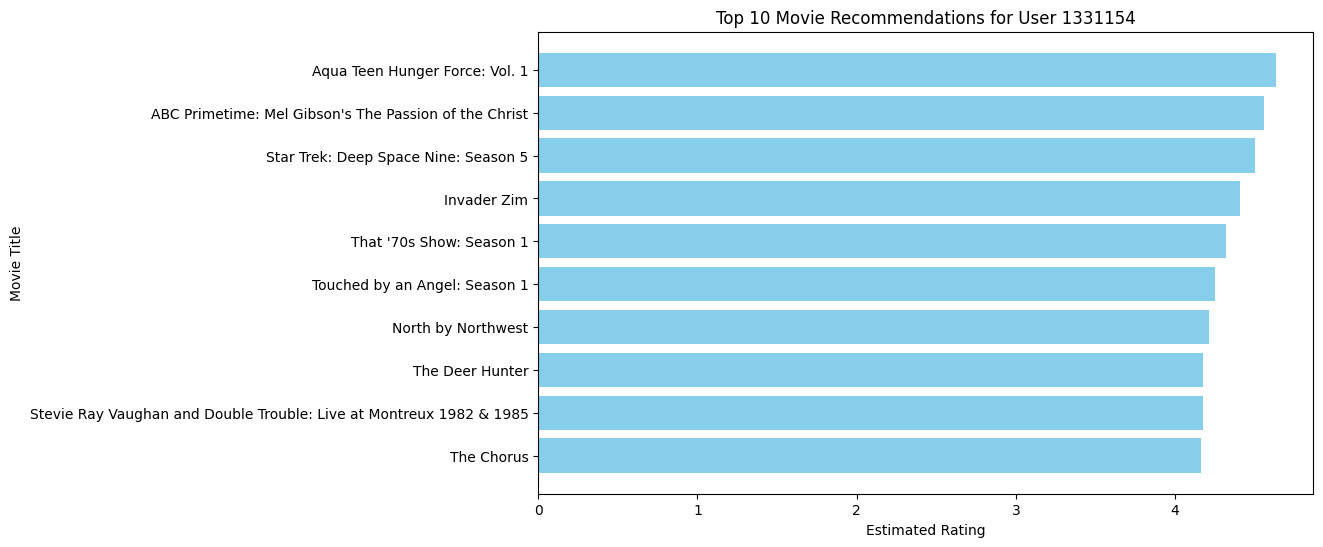

In [ ]:
# Step 1: Predict the ratings
user_number_656399 = df_title.copy()
user_number_656399 = user_number_656399[~user_number_656399["Movie_ID"].isin(Rejected_movies)]
user_number_656399["Estimate_Score"] = user_number_656399["Movie_ID"].apply(lambda x: model.predict(656399, x).est)

# Step 2: Sort the predictions
user_number_656399 = user_number_656399.sort_values("Estimate_Score", ascending=False)

# Step 3: Visualize the top 10 recommendations
top_10_recommendations = user_number_656399.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_10_recommendations['Name'], top_10_recommendations['Estimate_Score'], color='skyblue')
plt.xlabel('Estimated Rating')
plt.ylabel('Movie Title')
plt.title('Top 10 Movie Recommendations for User 1331154')
plt.gca().invert_yaxis()
plt.show()

In [ ]:
user_number_656399.head(10)

,Movie_ID,Year,Name,Estimate_Score
32,33,2000.0,Aqua Teen Hunger Force: Vol. 1,4.635011
31,32,2004.0,ABC Primetime: Mel Gibson's The Passion of the...,4.560932
208,209,1996.0,Star Trek: Deep Space Nine: Season 5,4.498503
67,68,2004.0,Invader Zim,4.405131
214,215,1998.0,That '70s Show: Season 1,4.318862
266,267,1994.0,Touched by an Angel: Season 1,4.250516
240,241,1959.0,North by Northwest,4.209970
198,199,1978.0,The Deer Hunter,4.176342
105,106,2004.0,Stevie Ray Vaughan and Double Trouble: Live at...,4.173608
166,167,2004.0,The Chorus,4.160973


Print all five users top 2 recommendations

In [ ]:
print(user_number_656399.head(2)), "\n"
print(user_number_267802.head(2)), "\n"
print(user_number_1055714.head(2)), "\n"
print(user_number_1331154.head(2)), "\n"
print(user_number_293198.head(2))

    Movie_ID    Year                                               Name  \
32        33  2000.0                     Aqua Teen Hunger Force: Vol. 1   
31        32  2004.0  ABC Primetime: Mel Gibson's The Passion of the...   

    Estimate_Score  
32        4.635011  
31        4.560932  
     Movie_ID    Year                                               Name  \
269       270  2001.0                         Sex and the City: Season 4   
31         32  2004.0  ABC Primetime: Mel Gibson's The Passion of the...   

     Estimate_Score  
269        4.337812  
31         4.231699  
     Movie_ID    Year                            Name  Estimate_Score
137       138  1995.0    Star Trek: Voyager: Season 1        5.000000
32         33  2000.0  Aqua Teen Hunger Force: Vol. 1        4.855589
   Movie_ID    Year                        Name
0         1  2003.0             Dinosaur Planet
1         2  2004.0  Isle of Man TT 2004 Review
     Movie_ID    Year                                  Name  E

Print using for loop

In [ ]:
user_numbers = [user_number_656399, user_number_267802, user_number_1055714, user_number_1331154, user_number_293198]

for user_number in user_numbers:
    print(user_number.head(2))


    Movie_ID    Year                                               Name  \
32        33  2000.0                     Aqua Teen Hunger Force: Vol. 1   
31        32  2004.0  ABC Primetime: Mel Gibson's The Passion of the...   

    Estimate_Score  
32        4.635011  
31        4.560932  
     Movie_ID    Year                                               Name  \
269       270  2001.0                         Sex and the City: Season 4   
31         32  2004.0  ABC Primetime: Mel Gibson's The Passion of the...   

     Estimate_Score  
269        4.337812  
31         4.231699  
     Movie_ID    Year                            Name  Estimate_Score
137       138  1995.0    Star Trek: Voyager: Season 1        5.000000
32         33  2000.0  Aqua Teen Hunger Force: Vol. 1        4.855589
   Movie_ID    Year                        Name
0         1  2003.0             Dinosaur Planet
1         2  2004.0  Isle of Man TT 2004 Review
     Movie_ID    Year                                  Name  E

Print using for loop and displaying each user name

In [ ]:
user_numbers = [user_number_656399, user_number_267802, user_number_1055714, user_number_1331154, user_number_293198]

for idx, user_number in enumerate(user_numbers, start=1):
    print(f"user_number_{idx}.head(2):\n", user_number.head(2), "\n")


user_number_1.head(2):
     Movie_ID    Year                                               Name  \
32        33  2000.0                     Aqua Teen Hunger Force: Vol. 1   
31        32  2004.0  ABC Primetime: Mel Gibson's The Passion of the...   

    Estimate_Score  
32        4.635011  
31        4.560932   

user_number_2.head(2):
      Movie_ID    Year                                               Name  \
269       270  2001.0                         Sex and the City: Season 4   
31         32  2004.0  ABC Primetime: Mel Gibson's The Passion of the...   

     Estimate_Score  
269        4.337812  
31         4.231699   

user_number_3.head(2):
      Movie_ID    Year                            Name  Estimate_Score
137       138  1995.0    Star Trek: Voyager: Season 1        5.000000
32         33  2000.0  Aqua Teen Hunger Force: Vol. 1        4.855589 

user_number_4.head(2):
    Movie_ID    Year                        Name
0         1  2003.0             Dinosaur Planet
1       

Here we have completed the  top movies recommandation from  Capstone Project Netflix dataset